# 04 EDA — PalletLogs

วิเคราะห์ข้อมูลการเคลื่อน Pallet ไปยัง Checker Location

**Sections**
1. Load Data
2. Volume & Throughput Over Time
3. Time Patterns (Hour / DayOfWeek)
4. Location Analysis
5. Product Analysis
6. Amount & PackSize Distribution
7. Operator Analysis
8. Floor & Row Distribution
9. Business Insights Summary

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid', palette='muted')

FIGURE_DIR = Path('../../reports/figures/palletlogs')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded')

Libraries loaded


## 1. Load Data

In [14]:
DATA_PATH = Path('../../data/interim/palletlogs/palletlogs_clean.csv')
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig', parse_dates=['StampDateTime'])

# derive time features
df['Date']      = df['StampDateTime'].dt.date
df['Hour']      = df['StampDateTime'].dt.hour
df['DayOfWeek'] = df['StampDateTime'].dt.day_name()
df['Month']     = df['StampDateTime'].dt.to_period('M')
df['YearMonth'] = df['StampDateTime'].dt.to_period('M').astype(str)

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["StampDateTime"].min()} → {df["StampDateTime"].max()}')
df.head()

Shape  : (309064, 33)
Columns: ['PalletID', 'Action', 'PalletStatus', 'PackSize', 'Amount', 'LotNo', 'MaterialCode', 'NameThai', 'ProductType', 'Model', 'Profile', 'Curve', 'Coat', 'ProductClass', 'StampDateTime', 'FromLocationType', 'FromLocationCode', 'FromLocationName', 'FromRowNo', 'FromColNo', 'FromFloorNo', 'ToLocationType', 'ToLocationCode', 'ToLocationName', 'ToColNo', 'ToFloorNo', 'UserCreate', 'UserCreateCode', 'Date', 'Hour', 'DayOfWeek', 'Month', 'YearMonth']
Date range: 2025-01-02 07:30:08 → 2026-05-18 10:51:20


,PalletID,Action,PalletStatus,PackSize,Amount,LotNo,MaterialCode,NameThai,ProductType,Model,...,ToLocationName,ToColNo,ToFloorNo,UserCreate,UserCreateCode,Date,Hour,DayOfWeek,Month,YearMonth
0,SB1-1LS3690515P025,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),0,0,ชัยณรงค์ เพ็ชรนิล,2102000002,2026-05-18,10,Monday,2026-05,2026-05
1,SB1-1LS3690515P026,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),0,0,ชัยณรงค์ เพ็ชรนิล,2102000002,2026-05-18,10,Monday,2026-05,2026-05
2,SB1-1LS3690515P024,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),0,0,&#3626;&#3640;&#3614;&#3633;&#3602;&#3609;&#36...,2506000001,2026-05-18,10,Monday,2026-05,2026-05
3,SB1-1LS3690515P023,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),0,0,พัสกร จันหอม,2102000001,2026-05-18,10,Monday,2026-05,2026-05
4,SB1-1LS3690515P021,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),0,0,&#3626;&#3640;&#3614;&#3633;&#3602;&#3609;&#36...,2506000001,2026-05-18,10,Monday,2026-05,2026-05


### Overview Statistics

In [15]:
print('=== Overview ===')
print(f'Total pallet movements : {len(df):,}')
print(f'Unique PalletIDs       : {df["PalletID"].nunique():,}')
print(f'Unique Operators       : {df["UserCreate"].nunique():,}')
print(f'Unique From Locations  : {df["FromLocationName"].nunique():,}')
print(f'Unique To Locations    : {df["ToLocationName"].nunique():,}')
print(f'Date range             : {df["StampDateTime"].min().date()} → {df["StampDateTime"].max().date()}')
print()
print('=== Amount Stats ===')
print(df[['Amount', 'PackSize']].describe().round(2))

=== Overview ===
Total pallet movements : 309,064
Unique PalletIDs       : 308,333
Unique Operators       : 16
Unique From Locations  : 60,059
Unique To Locations    : 10
Date range             : 2025-01-02 → 2026-05-18

=== Amount Stats ===
          Amount   PackSize
count  309064.00  309064.00
mean      219.93     219.93
std        37.47      37.47
min        45.00      45.00
25%       180.00     180.00
50%       240.00     240.00
75%       240.00     240.00
max       320.00     320.00


## 2. Volume & Throughput Over Time

จำนวน pallet ที่ถูกเคลื่อนในแต่ละวัน / เดือน

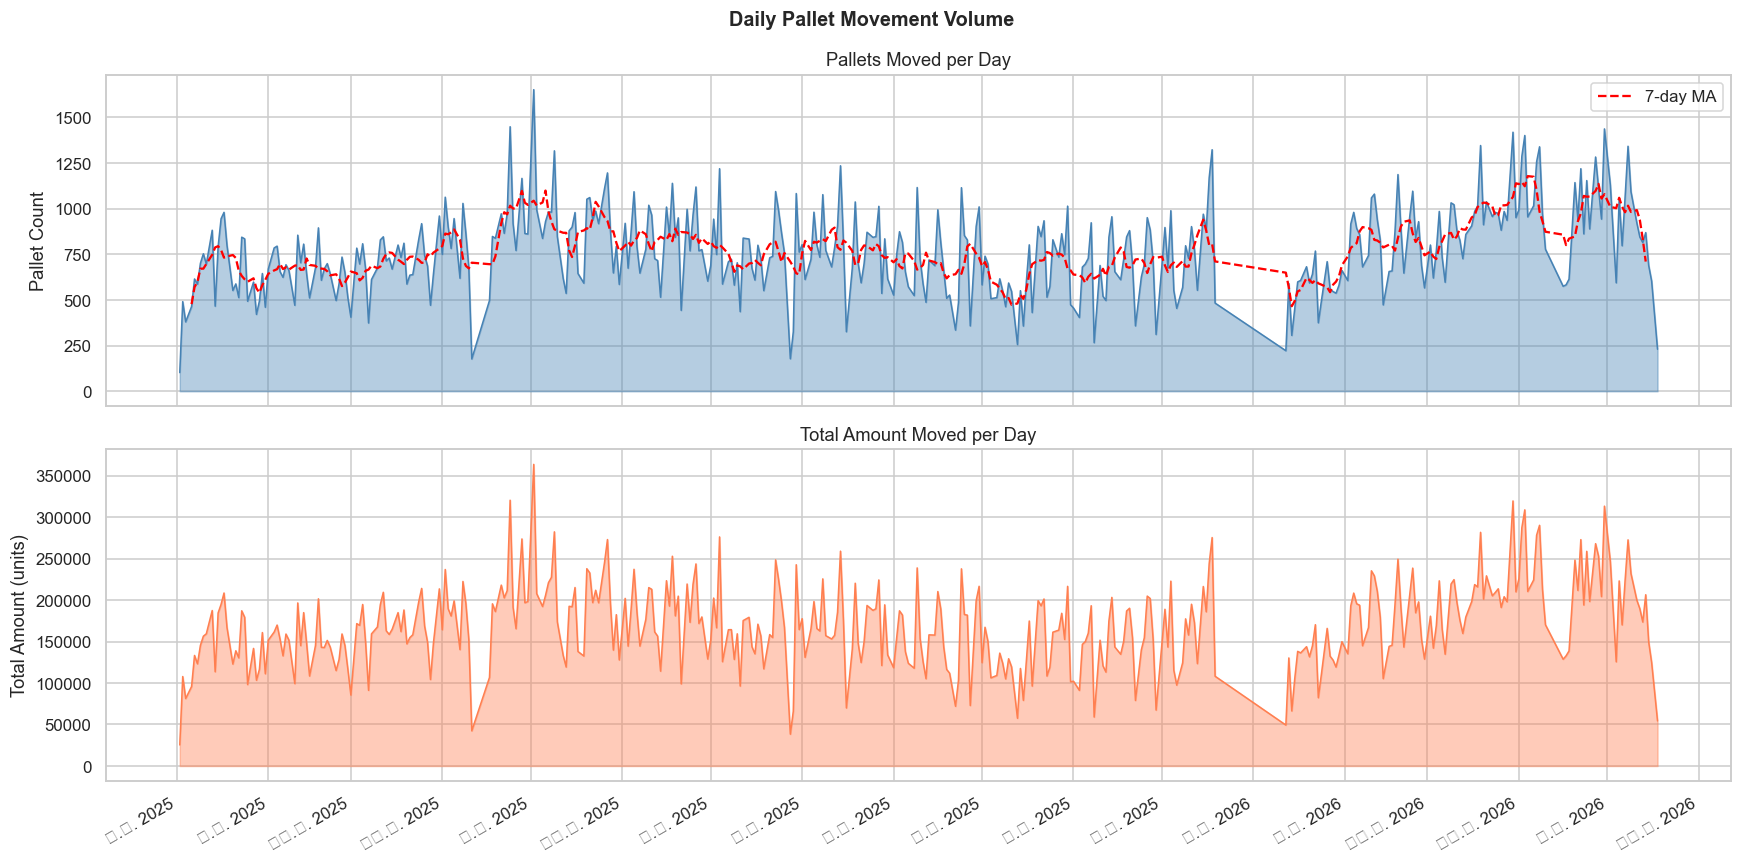

Figure saved


In [16]:
daily = df.groupby('Date').agg(
    pallet_count=('PalletID', 'count'),
    total_amount=('Amount', 'sum'),
).reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Daily Pallet Movement Volume', fontsize=13, fontweight='bold')

ax = axes[0]
ax.fill_between(daily['Date'], daily['pallet_count'], alpha=0.4, color='steelblue')
ax.plot(daily['Date'], daily['pallet_count'], color='steelblue', lw=1)
ax.set_ylabel('Pallet Count')
ax.set_title('Pallets Moved per Day')
rolling_7 = daily['pallet_count'].rolling(7, center=True).mean()
ax.plot(daily['Date'], rolling_7, color='red', lw=1.5, ls='--', label='7-day MA')
ax.legend()

ax = axes[1]
ax.fill_between(daily['Date'], daily['total_amount'], alpha=0.4, color='coral')
ax.plot(daily['Date'], daily['total_amount'], color='coral', lw=1)
ax.set_ylabel('Total Amount (units)')
ax.set_title('Total Amount Moved per Day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_01_daily_volume.png', bbox_inches='tight')
plt.show()
print('Figure saved')

=== Monthly Summary ===
YearMonth  pallet_count  total_amount  unique_pallets
  2025-01         16098       3573734           15912
  2025-02         16048       3552191           15991
  2025-03         18273       4268990           18269
  2025-04         18828       4189260           18828
  2025-05         23856       5235894           23852
  2025-06         20954       4628248           20944
  2025-07         19903       4376654           19872
  2025-08         20517       4410438           20517
  2025-09         18424       3995712           18424
  2025-10         17241       3722803           17236
  2025-11         16600       3624992           16600
  2025-12         13418       2897168           13418
  2026-01          9921       2236188            9919
  2026-02         20053       4373674           20005
  2026-03         24132       5265220           24132
  2026-04         22752       5029644           22750
  2026-05         12046       2591028           12036


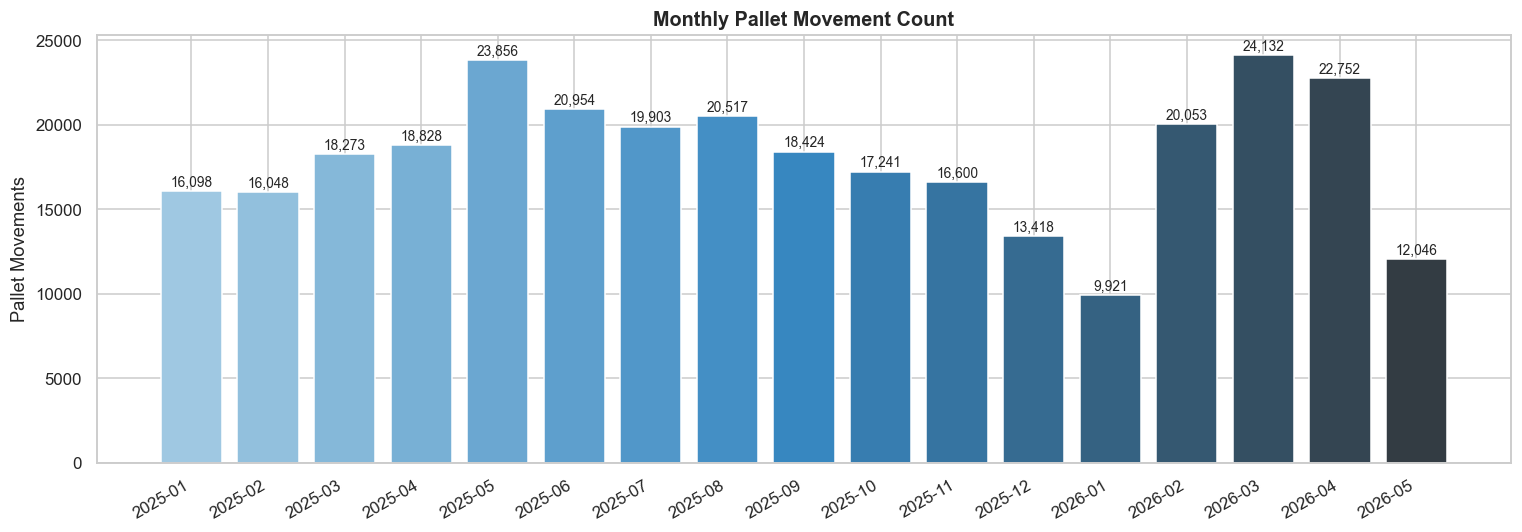

Figure saved


In [17]:
monthly = df.groupby('YearMonth').agg(
    pallet_count=('PalletID', 'count'),
    total_amount=('Amount', 'sum'),
    unique_pallets=('PalletID', 'nunique'),
).reset_index()

print('=== Monthly Summary ===')
print(monthly.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly))
bars = ax.bar(x, monthly['pallet_count'], color=sns.color_palette('Blues_d', len(monthly)), edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(monthly['YearMonth'], rotation=30, ha='right')
ax.set_ylabel('Pallet Movements')
ax.set_title('Monthly Pallet Movement Count', fontsize=13, fontweight='bold')
for bar, val in zip(bars, monthly['pallet_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_02_monthly_volume.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 3. Time Patterns (Hour / Day of Week)

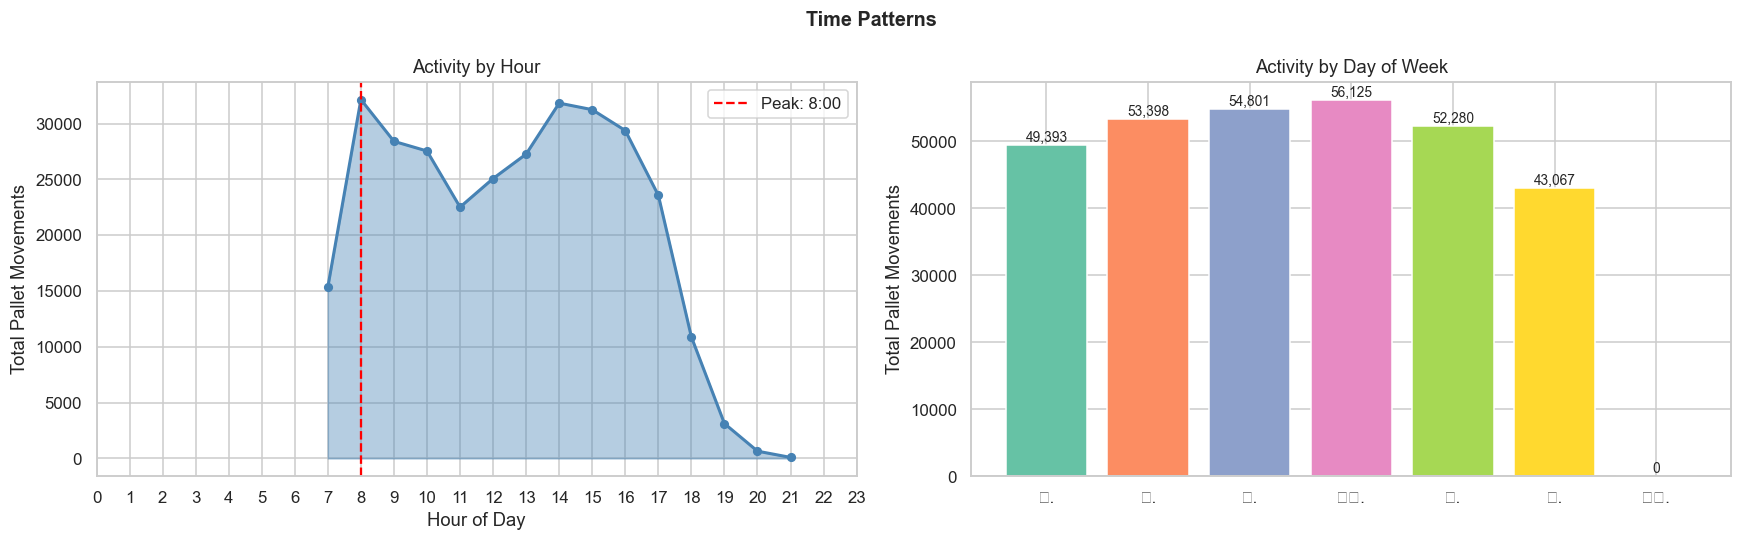

Figure saved


In [18]:
hour_stats = df.groupby('Hour').agg(
    pallet_count=('PalletID', 'count'),
    avg_amount=('Amount', 'mean'),
)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_labels = ['จ.','อ.','พ.','พฤ.','ศ.','ส.','อา.']
# fillna(0) หลัง reindex เพื่อป้องกัน NaN ในวันที่ไม่มีข้อมูล
dow_stats = df.groupby('DayOfWeek').agg(
    pallet_count=('PalletID', 'count'),
).reindex(dow_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Time Patterns', fontsize=13, fontweight='bold')

ax = axes[0]
ax.fill_between(hour_stats.index, hour_stats['pallet_count'], alpha=0.4, color='steelblue')
ax.plot(hour_stats.index, hour_stats['pallet_count'], 'o-', color='steelblue', ms=5, lw=2)
ax.set_xticks(range(0, 24, 1))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Pallet Movements')
ax.set_title('Activity by Hour')
peak_hour = hour_stats['pallet_count'].idxmax()
ax.axvline(peak_hour, color='red', ls='--', lw=1.5, label=f'Peak: {peak_hour}:00')
ax.legend()

ax = axes[1]
colors_dow = sns.color_palette('Set2', 7)
bars = ax.bar(range(7), dow_stats['pallet_count'], color=colors_dow, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_ylabel('Total Pallet Movements')
ax.set_title('Activity by Day of Week')
for bar, val in zip(bars, dow_stats['pallet_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_03_time_patterns.png', bbox_inches='tight')
plt.show()
print('Figure saved')

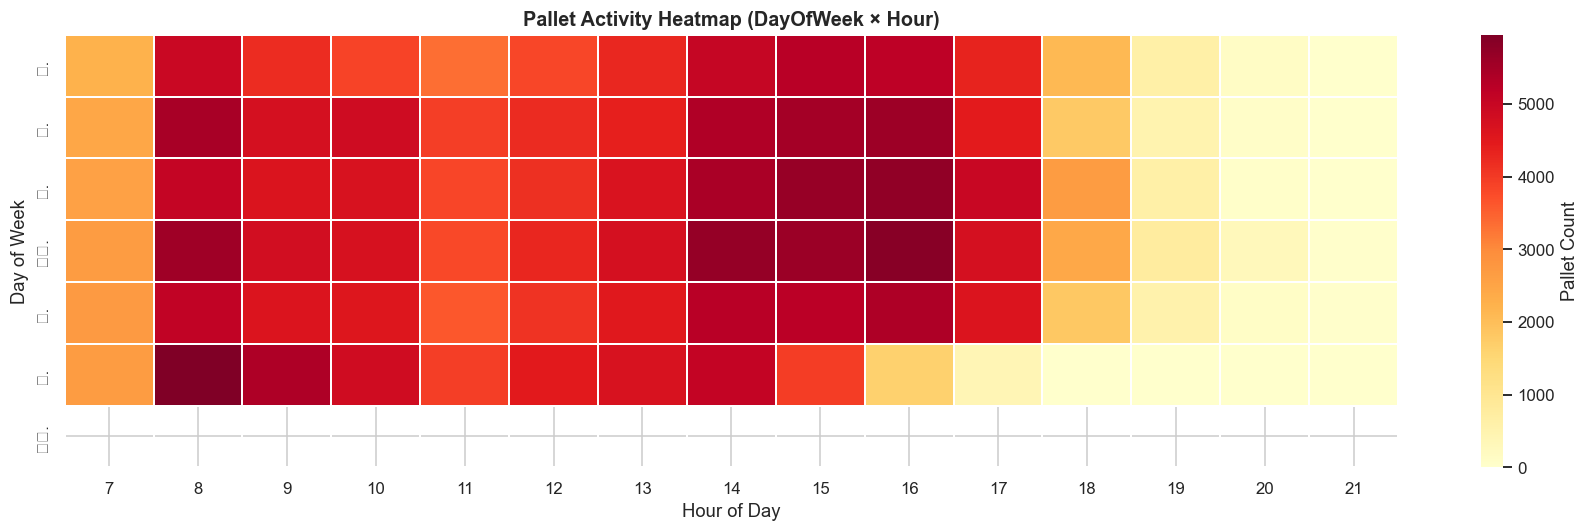

Figure saved


In [19]:
heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['PalletID'].count().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(dow_order)
heatmap_data.index = dow_labels

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Pallet Count'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Pallet Activity Heatmap (DayOfWeek × Hour)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_04_heatmap_dow_hour.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 4. Location Analysis

ดู FromLocation และ ToLocation ที่มีการเคลื่อน pallet มากที่สุด

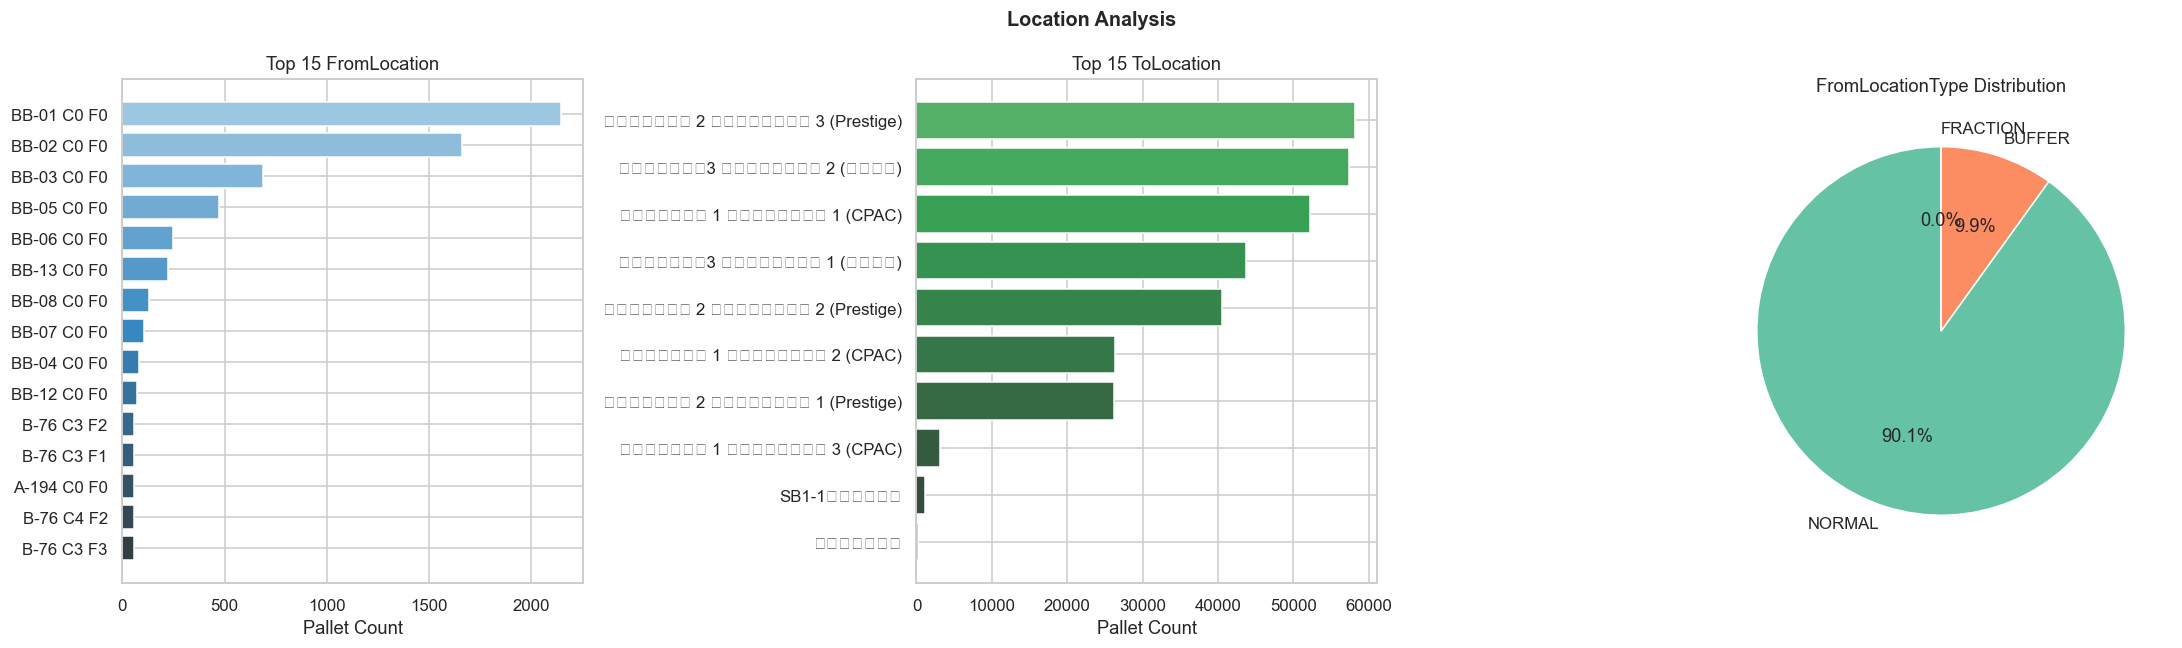

Figure saved


In [20]:
from_loc = df['FromLocationName'].value_counts().head(15)
to_loc   = df['ToLocationName'].value_counts().head(15)
from_type = df['FromLocationType'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Location Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
ax.barh(from_loc.index[::-1], from_loc.values[::-1],
        color=sns.color_palette('Blues_d', 15)[::-1], edgecolor='white')
ax.set_xlabel('Pallet Count')
ax.set_title('Top 15 FromLocation')

ax = axes[1]
ax.barh(to_loc.index[::-1], to_loc.values[::-1],
        color=sns.color_palette('Greens_d', 15)[::-1], edgecolor='white')
ax.set_xlabel('Pallet Count')
ax.set_title('Top 15 ToLocation')

ax = axes[2]
ax.pie(from_type.values, labels=from_type.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(from_type)), startangle=90)
ax.set_title('FromLocationType Distribution')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_05_location.png', bbox_inches='tight')
plt.show()
print('Figure saved')

In [21]:
print('=== FromLocationName top 20 ===')
print(df['FromLocationName'].value_counts().head(20).to_string())

print('\n=== ToLocationName top 15 ===')
print(df['ToLocationName'].value_counts().head(15).to_string())

=== FromLocationName top 20 ===
FromLocationName
BB-01 C0 F0    2145
BB-02 C0 F0    1662
BB-03 C0 F0     688
BB-05 C0 F0     473
BB-06 C0 F0     250
BB-13 C0 F0     225
BB-08 C0 F0     131
BB-07 C0 F0     108
BB-04 C0 F0      82
BB-12 C0 F0      72
B-76 C3 F2       58
B-76 C3 F1       56
A-194 C0 F0      56
B-76 C4 F2       55
B-76 C3 F3       55
B-76 C4 F1       54
B-75 C6 F2       53
B-76 C5 F2       53
B-74 C9 F1       52
B-74 C3 F3       52

=== ToLocationName top 15 ===
ToLocationName
ลานจ่าย 2 ช่องจ่าย 3 (Prestige)    58195
ลานจ่าย3 ช่องจ่าย 2 (ครอบ)         57434
ลานจ่าย 1 ช่องจ่าย 1 (CPAC)        52162
ลานจ่าย3 ช่องจ่าย 1 (ครอบ)         43757
ลานจ่าย 2 ช่องจ่าย 2 (Prestige)    40502
ลานจ่าย 1 ช่องจ่าย 2 (CPAC)        26270
ลานจ่าย 2 ช่องจ่าย 1 (Prestige)    26203
ลานจ่าย 1 ช่องจ่าย 3 (CPAC)         3098
SB1-1ลานโอน                         1194
อุปกรณ์                              249


## 5. Product Analysis

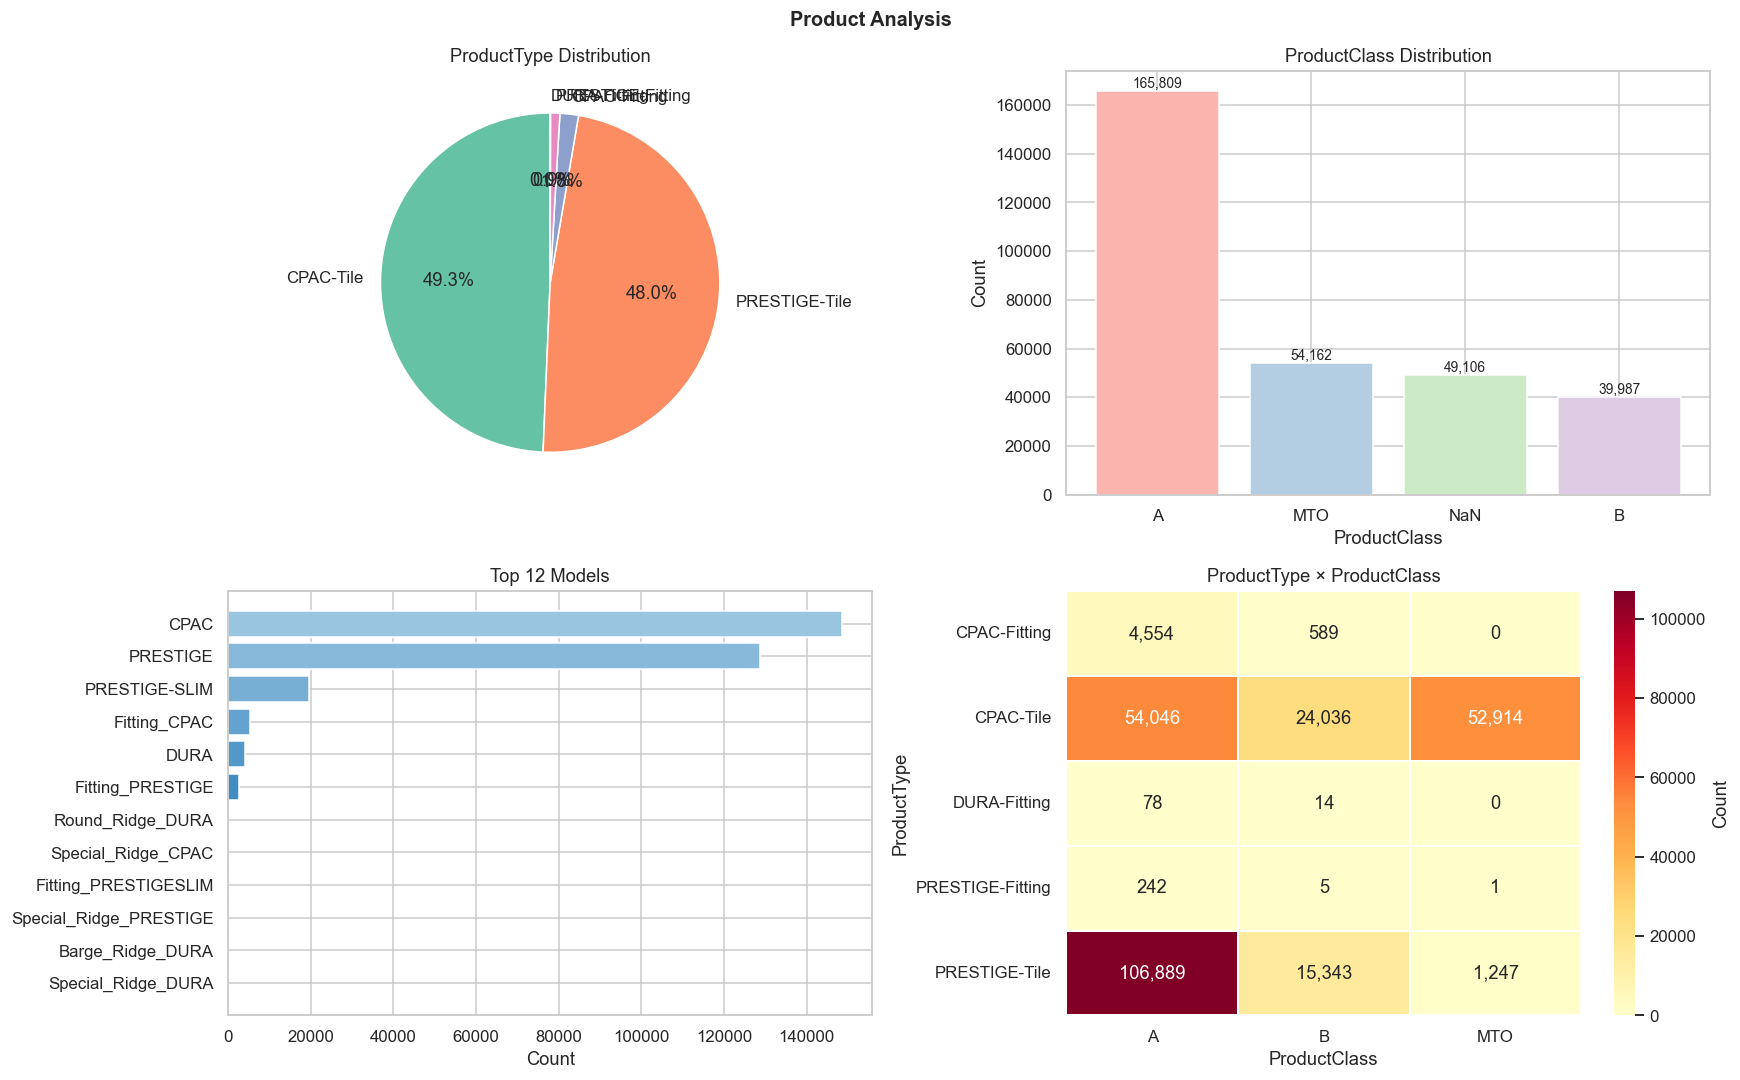

Figure saved


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Product Analysis', fontsize=13, fontweight='bold')

# ProductType
ax = axes[0, 0]
pt = df['ProductType'].value_counts(dropna=False)
colors_pt = sns.color_palette('Set2', len(pt))
ax.pie(pt.values, labels=[str(x) if pd.notna(x) else 'NaN' for x in pt.index],
       autopct='%1.1f%%', colors=colors_pt, startangle=90)
ax.set_title('ProductType Distribution')

# ProductClass — ใช้ list comprehension แปลง NaN → 'NaN' ก่อนส่งให้ matplotlib
ax = axes[0, 1]
pc = df['ProductClass'].value_counts(dropna=False)
pc_labels = [str(x) if pd.notna(x) else 'NaN' for x in pc.index]
bars = ax.bar(pc_labels, pc.values,
              color=sns.color_palette('Pastel1', len(pc)), edgecolor='white')
ax.set_title('ProductClass Distribution')
ax.set_xlabel('ProductClass')
ax.set_ylabel('Count')
for bar, val in zip(bars, pc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9)

# Top Models
ax = axes[1, 0]
model_counts = df['Model'].value_counts().head(12)
ax.barh(model_counts.index[::-1], model_counts.values[::-1],
        color=sns.color_palette('Blues_d', 12)[::-1], edgecolor='white')
ax.set_xlabel('Count')
ax.set_title('Top 12 Models')

# ProductType x ProductClass heatmap
ax = axes[1, 1]
pt_pc = df.groupby(['ProductType', 'ProductClass'])['PalletID'].count().unstack(fill_value=0)
sns.heatmap(pt_pc, annot=True, fmt=',', cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Count'})
ax.set_title('ProductType × ProductClass')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_06_product.png', bbox_inches='tight')
plt.show()
print('Figure saved')

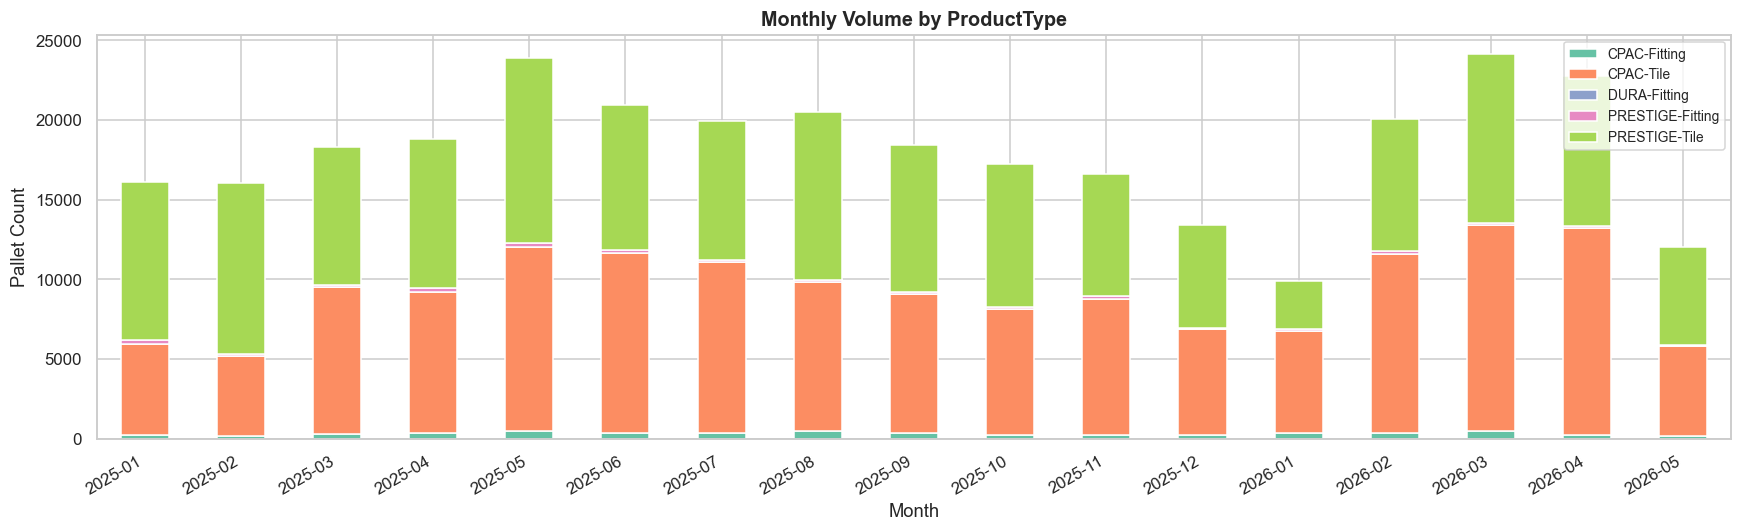

Figure saved


In [23]:
pt_monthly = df.groupby(['YearMonth', 'ProductType'])['PalletID'].count().unstack(fill_value=0)
pt_monthly.plot(kind='bar', stacked=True, figsize=(16, 5),
                color=sns.color_palette('Set2', pt_monthly.shape[1]))
plt.title('Monthly Volume by ProductType', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Pallet Count')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_07_product_trend.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 6. Amount & PackSize Distribution

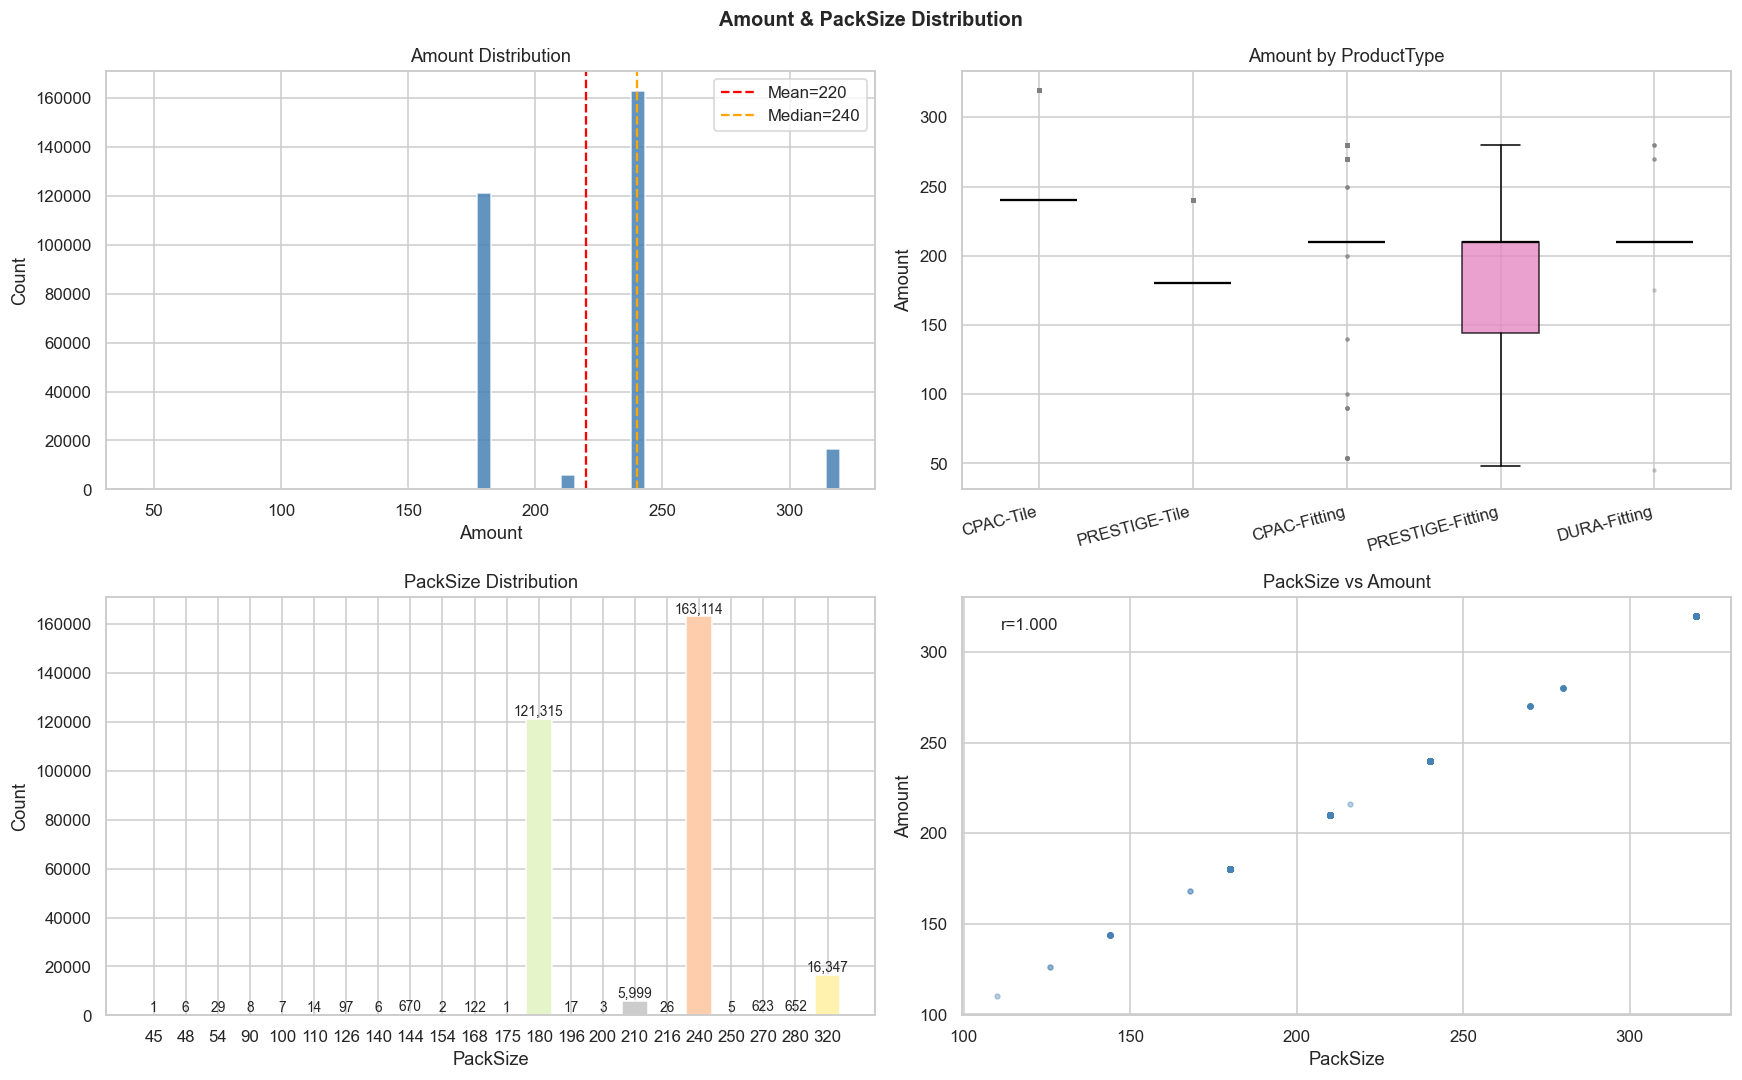

Figure saved


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Amount & PackSize Distribution', fontsize=13, fontweight='bold')

# Amount histogram
ax = axes[0, 0]
ax.hist(df['Amount'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['Amount'].mean(), color='red', ls='--', lw=1.5, label=f'Mean={df["Amount"].mean():.0f}')
ax.axvline(df['Amount'].median(), color='orange', ls='--', lw=1.5, label=f'Median={df["Amount"].median():.0f}')
ax.set_xlabel('Amount')
ax.set_ylabel('Count')
ax.set_title('Amount Distribution')
ax.legend()

# Amount by ProductType boxplot
ax = axes[0, 1]
pt_order = df['ProductType'].value_counts().index.tolist()
groups = [df[df['ProductType'] == t]['Amount'].dropna().values for t in pt_order]
bp = ax.boxplot(groups, tick_labels=[str(t) for t in pt_order], patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='.', markersize=4, alpha=0.3, markerfacecolor='gray', markeredgecolor='gray'))
colors_pt = sns.color_palette('Set2', len(pt_order))
for patch, c in zip(bp['boxes'], colors_pt):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.set_xticklabels([str(t) for t in pt_order], rotation=15, ha='right')
ax.set_ylabel('Amount')
ax.set_title('Amount by ProductType')

# PackSize value counts
ax = axes[1, 0]
pack_counts = df['PackSize'].value_counts().sort_index()
ax.bar(pack_counts.index.astype(str), pack_counts.values,
       color=sns.color_palette('Pastel2', len(pack_counts)), edgecolor='white')
ax.set_xlabel('PackSize')
ax.set_ylabel('Count')
ax.set_title('PackSize Distribution')
for i, (ps, val) in enumerate(pack_counts.items()):
    ax.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Amount vs PackSize scatter
ax = axes[1, 1]
sample = df.sample(min(10000, len(df)), random_state=42)
sc = ax.scatter(sample['PackSize'], sample['Amount'],
                alpha=0.2, s=10, color='steelblue')
ax.set_xlabel('PackSize')
ax.set_ylabel('Amount')
ax.set_title('PackSize vs Amount')
r_pa = df['PackSize'].corr(df['Amount'])
ax.text(0.05, 0.92, f'r={r_pa:.3f}', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_08_amount.png', bbox_inches='tight')
plt.show()
print('Figure saved')

In [25]:
df['FillRate'] = (df['Amount'] / df['PackSize']).where(df['PackSize'] > 0)

print('=== Fill Rate (Amount / PackSize) ===')
print(df['FillRate'].describe().round(3))

full_pallets = (df['FillRate'] >= 1.0).sum()
partial_pallets = (df['FillRate'] < 1.0).sum()
print(f'\nFull pallets (FillRate=1.0) : {full_pallets:,} ({full_pallets/len(df)*100:.1f}%)')
print(f'Partial pallets (FillRate<1) : {partial_pallets:,} ({partial_pallets/len(df)*100:.1f}%)')

=== Fill Rate (Amount / PackSize) ===
count    309064.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: FillRate, dtype: float64

Full pallets (FillRate=1.0) : 309,064 (100.0%)
Partial pallets (FillRate<1) : 0 (0.0%)


## 7. Operator Analysis

ดูว่า Operator คนไหนเคลื่อน pallet มากที่สุด และ pattern การทำงาน

=== Top 20 Operators by Pallet Count ===
                                                                                                                                                pallet_count  avg_amount  total_amount
UserCreate                                                                                                                                                                            
รัตนา ทองคำ                                                                                                                                            57621       192.7      11101820
ต้อม วิหะตานนท์                                                                                                                                        54820       193.9      10632224
บุญลือ วีระพันธ์                                                                                                                                       38486       227.9       8770978
พัสกร จันหอม                                

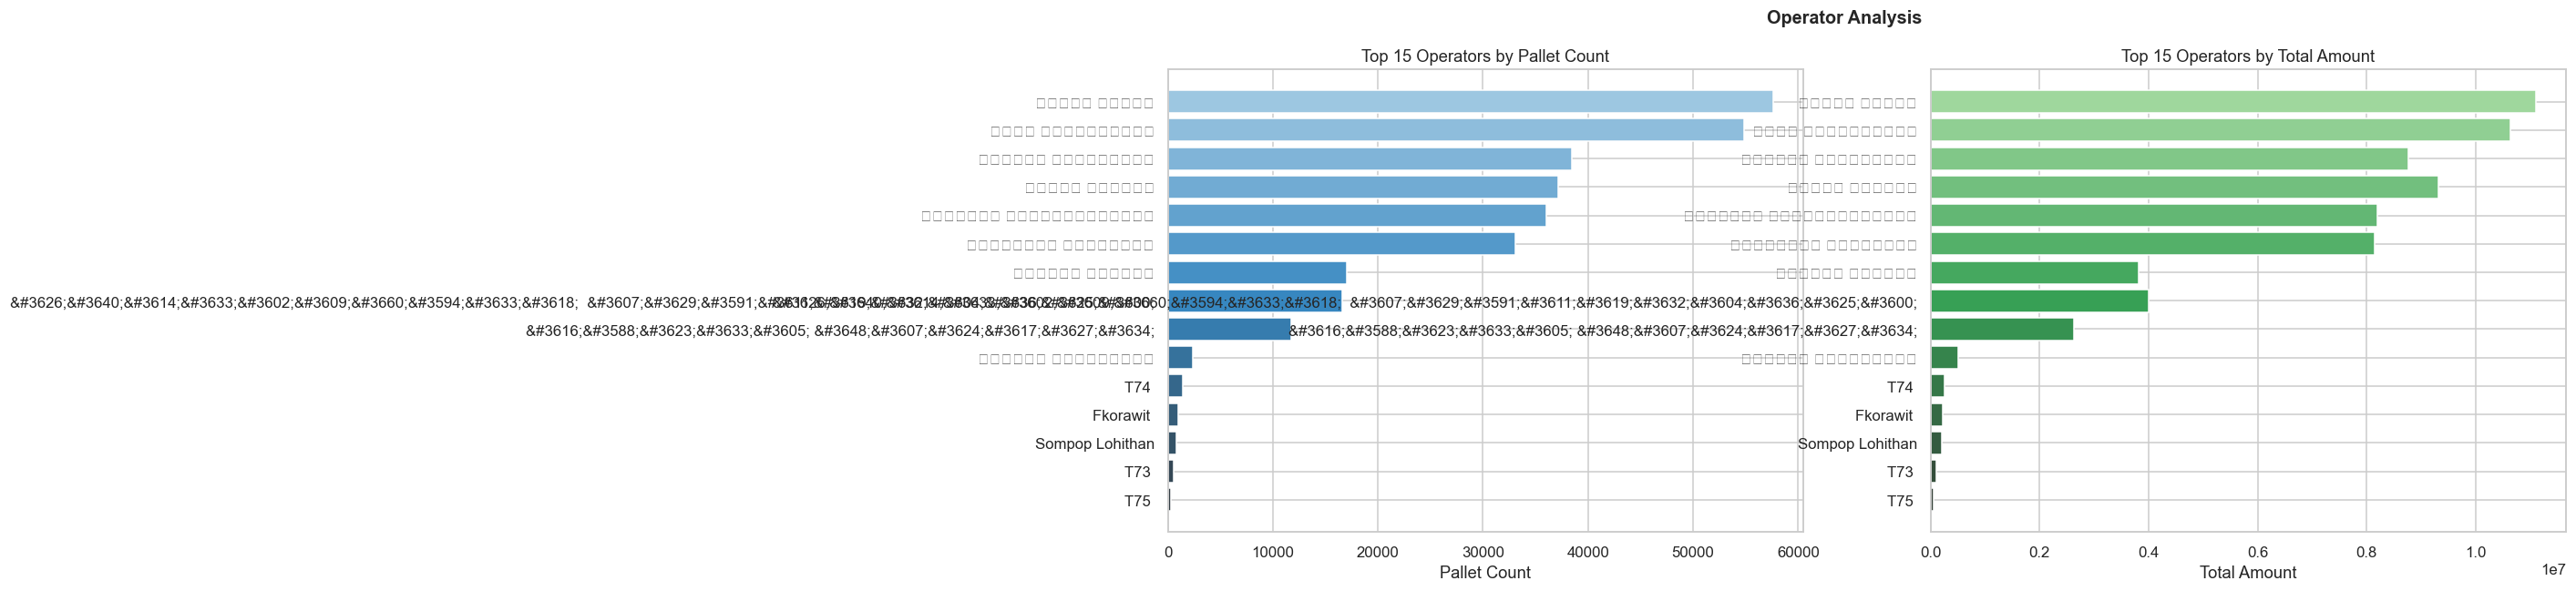

Figure saved


In [26]:
op_stats = df.groupby('UserCreate').agg(
    pallet_count=('PalletID', 'count'),
    avg_amount=('Amount', 'mean'),
    total_amount=('Amount', 'sum'),
).sort_values('pallet_count', ascending=False)

print('=== Top 20 Operators by Pallet Count ===')
print(op_stats.head(20).round(1).to_string())

top15_op = op_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Operator Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
ax.barh(top15_op.index[::-1], top15_op['pallet_count'][::-1],
        color=sns.color_palette('Blues_d', 15)[::-1], edgecolor='white')
ax.set_xlabel('Pallet Count')
ax.set_title('Top 15 Operators by Pallet Count')

ax = axes[1]
ax.barh(top15_op.index[::-1], top15_op['total_amount'][::-1],
        color=sns.color_palette('Greens_d', 15)[::-1], edgecolor='white')
ax.set_xlabel('Total Amount')
ax.set_title('Top 15 Operators by Total Amount')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_09_operator.png', bbox_inches='tight')
plt.show()
print('Figure saved')

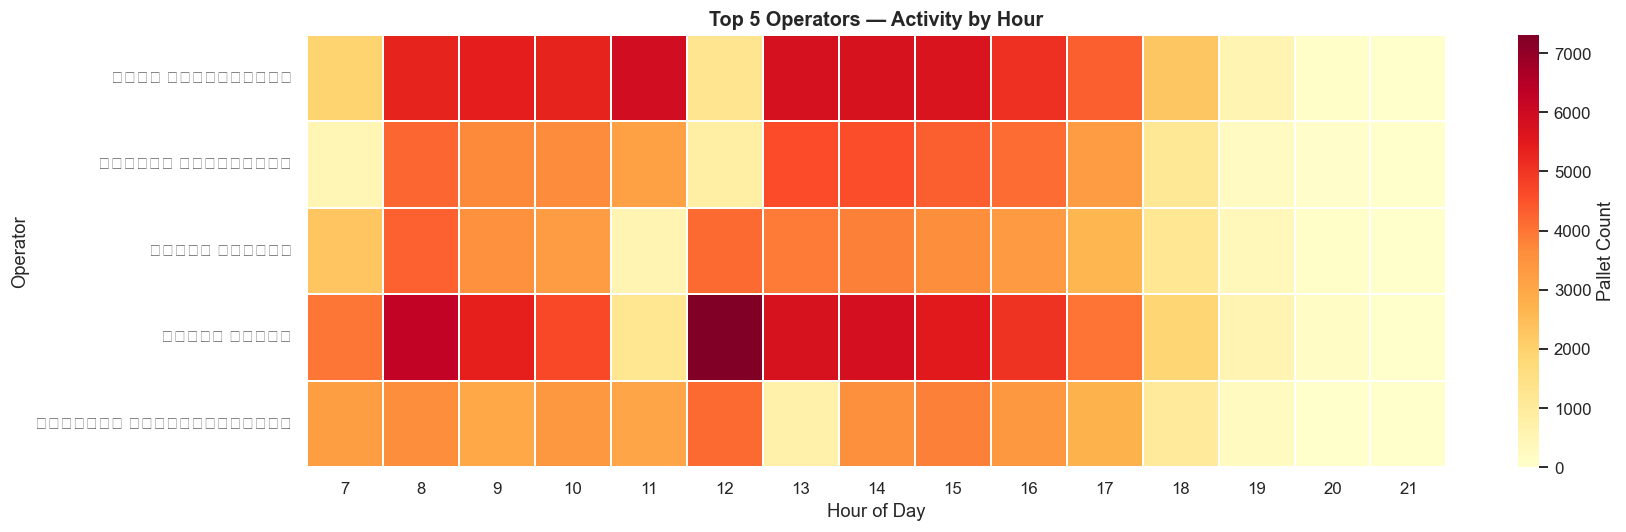

Figure saved


In [27]:
top5_ops = op_stats.head(5).index.tolist()
df_top5 = df[df['UserCreate'].isin(top5_ops)]

op_hour = df_top5.groupby(['UserCreate', 'Hour'])['PalletID'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(op_hour, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Pallet Count'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Operator')
ax.set_title('Top 5 Operators — Activity by Hour', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_10_operator_hour.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 8. Floor & Row Distribution

ดูว่า pallet ถูกหยิบจาก floor และ row ไหนบ่อยที่สุด

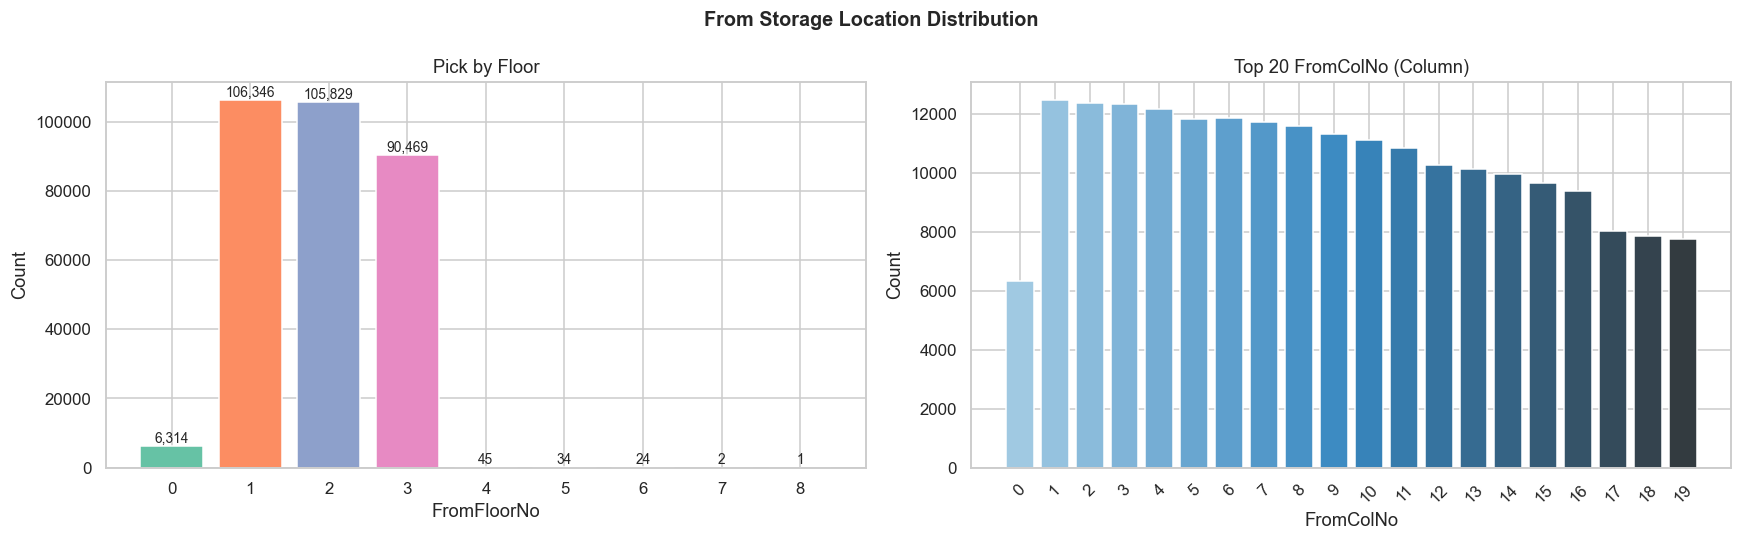

Figure saved


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('From Storage Location Distribution', fontsize=13, fontweight='bold')

# FromFloorNo
ax = axes[0]
floor_counts = df['FromFloorNo'].value_counts().sort_index()
ax.bar(floor_counts.index.astype(str), floor_counts.values,
       color=sns.color_palette('Set2', len(floor_counts)), edgecolor='white')
ax.set_xlabel('FromFloorNo')
ax.set_ylabel('Count')
ax.set_title('Pick by Floor')
for i, (fl, val) in enumerate(floor_counts.items()):
    ax.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

# FromColNo distribution
ax = axes[1]
col_counts = df['FromColNo'].value_counts().sort_index().head(20)
ax.bar(col_counts.index.astype(str), col_counts.values,
       color=sns.color_palette('Blues_d', len(col_counts)), edgecolor='white')
ax.set_xlabel('FromColNo')
ax.set_ylabel('Count')
ax.set_title('Top 20 FromColNo (Column)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_11_floor_col.png', bbox_inches='tight')
plt.show()
print('Figure saved')

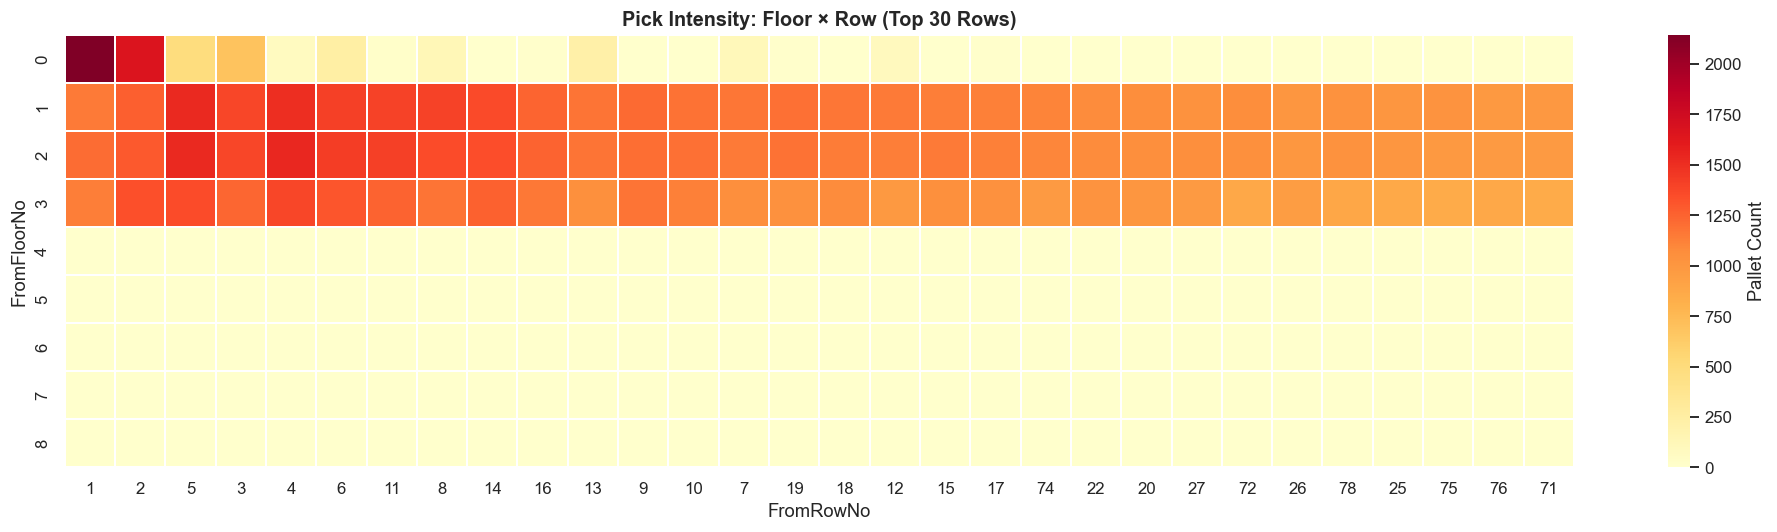

Figure saved


In [29]:
# Row × Floor heatmap
df['FromRowNo_int'] = df['FromRowNo'].fillna(0).astype(int)
hm = df.groupby(['FromFloorNo', 'FromRowNo_int'])['PalletID'].count().unstack(fill_value=0)
hm_show = hm.loc[:, hm.sum(axis=0).sort_values(ascending=False).head(30).index]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(hm_show, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Pallet Count'})
ax.set_xlabel('FromRowNo')
ax.set_ylabel('FromFloorNo')
ax.set_title('Pick Intensity: Floor × Row (Top 30 Rows)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_12_floor_row_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 8b. PalletStatus

ดูสัดส่วนสถานะของ pallet

=== PalletStatus ===
PalletStatus
FOLKPOSTEND      308819
POSTCOMPLETED       218
GOOD                 25
PACK                  2
Name: count, dtype: int64


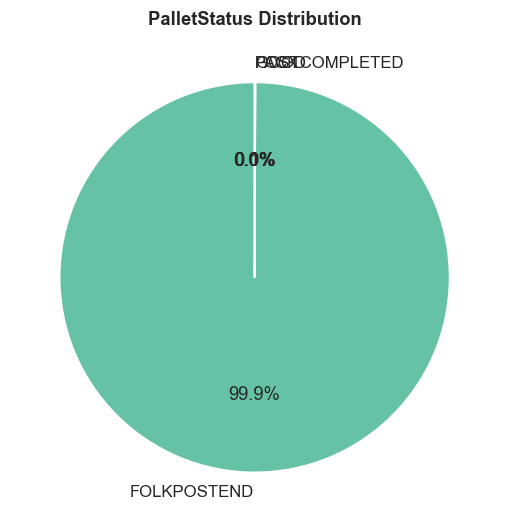

Figure saved


In [30]:
ps = df['PalletStatus'].value_counts(dropna=False)
print('=== PalletStatus ===')
print(ps)

fig, ax = plt.subplots(figsize=(8, 5))
ps_labels = [str(x) if pd.notna(x) else 'NaN' for x in ps.index]
ax.pie(ps.values, labels=ps_labels, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(ps)), startangle=90)
ax.set_title('PalletStatus Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_13_pallet_status.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 9. Business Insights Summary

In [31]:
print('=' * 65)
print('BUSINESS INSIGHTS — PalletLogs EDA')
print('=' * 65)

print(f'\n[Overview]')
print(f'  Total movements  : {len(df):,}')
print(f'  Unique PalletIDs : {df["PalletID"].nunique():,}')
print(f'  Date range       : {df["StampDateTime"].min().date()} → {df["StampDateTime"].max().date()}')
print(f'  Avg Amount/pallet: {df["Amount"].mean():.1f} units')

print(f'\n[Daily Volume]')
print(f'  Avg pallets/day  : {daily["pallet_count"].mean():.0f}')
print(f'  Max pallets/day  : {daily["pallet_count"].max():,}  ({daily.loc[daily["pallet_count"].idxmax(), "Date"].date()})')
print(f'  Min pallets/day  : {daily["pallet_count"].min():,}  ({daily.loc[daily["pallet_count"].idxmin(), "Date"].date()})')

print(f'\n[Time Pattern]')
peak_h = hour_stats['pallet_count'].idxmax()
low_h  = hour_stats['pallet_count'].idxmin()
print(f'  Peak hour        : {peak_h}:00  ({int(hour_stats.loc[peak_h, "pallet_count"]):,} movements)')
print(f'  Lowest hour      : {low_h}:00  ({int(hour_stats.loc[low_h, "pallet_count"]):,} movements)')

print(f'\n[ProductType]')
for pt_name, cnt in df['ProductType'].value_counts(dropna=False).items():
    print(f'  {str(pt_name):25s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

print(f'\n[ProductClass]')
for pc_name, cnt in df['ProductClass'].value_counts(dropna=False).items():
    print(f'  {str(pc_name):10s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

print(f'\n[Location]')
top_from = df['FromLocationName'].value_counts().index[0]
top_to   = df['ToLocationName'].value_counts().index[0]
print(f'  Most active FromLocation : {top_from}')
print(f'  Most active ToLocation   : {top_to}')

print(f'\n[Operator]')
top_op = op_stats.index[0]
print(f'  Most active operator : {top_op}  ({int(op_stats.loc[top_op, "pallet_count"]):,} pallets)')
print(f'  Total unique operators: {df["UserCreate"].nunique():,}')

print(f'\n[Fill Rate]')
full_pct = (df['FillRate'] >= 1.0).mean() * 100
print(f'  Full pallets (FillRate=1.0) : {full_pct:.1f}%')
print(f'  Avg FillRate               : {df["FillRate"].mean():.3f}')

print('\n' + '=' * 65)

BUSINESS INSIGHTS — PalletLogs EDA

[Overview]
  Total movements  : 309,064
  Unique PalletIDs : 308,333
  Date range       : 2025-01-02 → 2026-05-18
  Avg Amount/pallet: 219.9 units

[Daily Volume]
  Avg pallets/day  : 771
  Max pallets/day  : 1,652  (2025-05-02)
  Min pallets/day  : 102  (2025-01-02)

[Time Pattern]
  Peak hour        : 8:00  (32,152 movements)
  Lowest hour      : 21:00  (92 movements)

[ProductType]
  CPAC-Tile                : 152,475 (49.3%)
  PRESTIGE-Tile            : 148,301 (48.0%)
  CPAC-Fitting             : 5,453 (1.8%)
  PRESTIGE-Fitting         : 2,743 (0.9%)
  DURA-Fitting             : 92 (0.0%)

[ProductClass]
  A         : 165,809 (53.6%)
  MTO       : 54,162 (17.5%)
  nan       : 49,106 (15.9%)
  B         : 39,987 (12.9%)

[Location]
  Most active FromLocation : BB-01 C0 F0
  Most active ToLocation   : ลานจ่าย 2 ช่องจ่าย 3 (Prestige)

[Operator]
  Most active operator : รัตนา ทองคำ  (57,621 pallets)
  Total unique operators: 16

[Fill Rate]
  Full 